In [3]:
import os
from dotenv import load_dotenv
import databento as db
import pandas as pd

load_dotenv()
client = db.Historical(os.environ.get("DATABENTO_API_KEY"))

In [ ]:
# !!!ONLY RUN IF THERE IS NO EXISTING DATA IN /data OR IF YOU WANT NEW DATA!!!
data = client.timeseries.get_range(
    dataset="XNAS.ITCH",
    symbols="AAPL",
    schema="trades",
    start="2024-01-02",
    end="2025-01-02",
    path="../data/aapl_trades.dbn.zst",
)

store = db.DBNStore.from_file("../data/aapl_trades.dbn.zst")
store.to_parquet("../data/aapl_trades.parquet")

In [4]:
raw = pd.read_parquet(
    "../data/aapl_trades.parquet",
    filters=[
        ("ts_event", ">=", pd.Timestamp("2024-01-01", tz="UTC")),
        ("ts_event", "<",  pd.Timestamp("2024-02-01", tz="UTC")),
    ],
)

In [6]:
# Keep only valid trades (i.e., those with a non-zero price and size)
df = raw[(raw["price"] > 0) & (raw["size"] > 0)].copy()

# Set the index to the exchange measured timestamp
df = df.set_index("ts_event")

# Convert the index to the New York timezone
df.index = df.index.tz_convert("America/New_York")

# Filter the DataFrame to only include rows between 9:30 AM and 4:00 PM
df = df.between_time("09:30:01", "15:59:59")

# Sanity check the price scale before going further
print(df["price"].describe())

count    2.270292e+06
mean     1.874750e+02
std      4.619991e+00
min      1.801750e+02
25%      1.839700e+02
50%      1.859300e+02
75%      1.915300e+02
max      1.963700e+02
Name: price, dtype: float64


In [7]:
# Define a daily_rv function that takes df and freq and returns a DataFrame with daily realized volatility
import numpy as np

def daily_rv(df, freq):
    day = df.index.normalize()
    prices = (
        df["price"]
        .groupby(day)
        .resample(freq)
        .last()
        .ffill()
        .droplevel(0)
    )

    #Get opening price for each day
    opens = df["price"].groupby(day).first()

    #Add openings to resampled prices
    prices = pd.concat([opens, prices]).sort_index()
    
    logp = np.log(prices)

    rv_daily = (
        logp.groupby(logp.index.normalize())
        .apply(lambda x: (x.diff() ** 2).sum())
    )

    return rv_daily

In [ ]:
# Create a df that contains the daily realized volatility for each frequency in freqs

freqs = [".01s", "1s", "2s", "5s", "10s", "30s", "1min", "2min", "5min", "10min", "30min"]

rv = pd.DataFrame({f: daily_rv(df, f) for f in freqs})

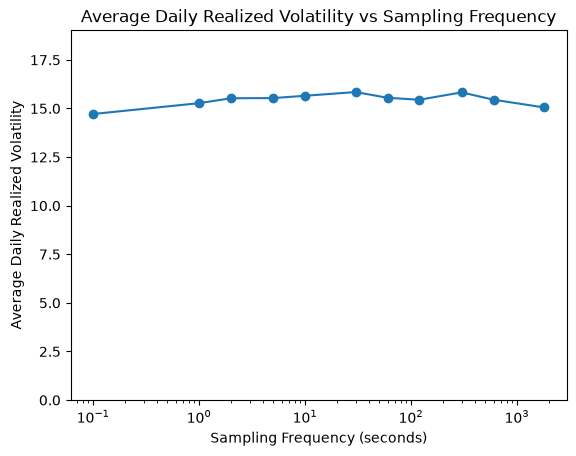

In [ ]:
import matplotlib.pyplot as plt

seconds = [0.01 ,1, 2, 5, 10, 30, 60, 120, 300, 600, 1800]

means_annualized = np.sqrt(rv.mean() * 252) * 100  # Annualize and convert to percentage

plt.semilogx(seconds, means_annualized, marker="o")
plt.ylim(0, means_annualized.max() * 1.2)
plt.xlabel("Sampling Frequency (seconds)")
plt.ylabel("Average Daily Realized Volatility")
plt.title("Average Daily Realized Volatility vs Sampling Frequency")
plt.show()